# Customer Buying Behavior Analysis

## Objective
The goal of this project is to:
- Analyze customer buying patterns across food categories
- Understand relationships between sales, unit sales, and market share
- Build predictive models for sales and growth trends

## Dataset Overview
This dataset contains weekly sales data across multiple food categories, including:
- Sales (Dollars)
- Unit Sales
- Market Share
- Historical comparisons (last year, 3 years ago)


In [776]:
filename = "Variables.txt" 
with open(filename, "r") as file:
    for line in file:
        if len(line) > 20:
            print(line)

Variable name	Definition

Category	Food category

Subcategory	Food subcategory

Dollars	Total value of sales

Dollars last year	Total value of sales, same week last year

Dollars 3 years ago	Total value of sales, same week 3 years ago (available starting May 2022 with data beginning October 3, 2021)

Unit sales	Total units sold, any size

Unit sales last year	Total units sold, any size, same week last year

Unit sales 3 years ago	Total units sold, any size, same week 3 years ago (available starting May 2022 with data beginning October 3, 2021)

Share	Category share of total dollar sales

Share last year	Category share of total dollar sales, same week last year

Share 3 years ago	Category share of total dollar sales, same week 3 years ago (available starting May 2022 with data beginning October 3, 2021)

Percent change dollars 1 year	Change in sales value since same week last year, as a percent of last year's sales value

Percent change units 1 year	Change in units sold of any size sinc

In [777]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [778]:
# read the XLSX file into a pandas DataFrame
df = pd.read_excel('../data/Raw_Data.xlsx')

# display the first 5 rows of the DataFrame
df.head()

,Date,Category,Subcategory,Dollars,Dollars_last_year,Dollars_3_years_ago,Unit_sales,Unit_sales_last_year,Unit_sales_3_years_ago,Share,Share_last_year,Share_3_years_ago,Percent_change_dollars_1_year,Percent_change_units_1_year,Percent_change_share_1_year,Percent_change_dollars_3_years,Percent_change_units_3_years,Percent_change_share_3_years
0,2019-10-06,Alcohol,Other,1150829004,1104600595,NaN,150101757,145532385,NaN,8.8,8.6,NaN,4.2,3.1,2.5,NaN,NaN,NaN
1,2019-10-06,All foods,All foods,13043274747,12832064544,NaN,4473321014,4502907925,NaN,100.0,100.0,NaN,1.6,-0.7,0.0,NaN,NaN,NaN
2,2019-10-06,Beverages,Carbonated non-alcoholic,735071266,731136055,NaN,314494539,325449264,NaN,5.6,5.7,NaN,0.5,-3.4,-1.1,NaN,NaN,NaN
3,2019-10-06,Beverages,Fruit drinks and non-carbonated sugary,729071094,686222934,NaN,310128337,296950839,NaN,5.6,5.3,NaN,6.2,4.4,4.5,NaN,NaN,NaN
4,2019-10-06,Beverages,Other,227199281,228647614,NaN,36083021,36681533,NaN,1.7,1.8,NaN,-0.6,-1.6,-2.2,NaN,NaN,NaN


In [779]:
# Get the first 5 rows of the dataframe
df.tail()

,Date,Category,Subcategory,Dollars,Dollars_last_year,Dollars_3_years_ago,Unit_sales,Unit_sales_last_year,Unit_sales_3_years_ago,Share,Share_last_year,Share_3_years_ago,Percent_change_dollars_1_year,Percent_change_units_1_year,Percent_change_share_1_year,Percent_change_dollars_3_years,Percent_change_units_3_years,Percent_change_share_3_years
10147,2023-05-07,Vegetables,Other-mostly water fresh/frozen,159462661,160671897,173696772.0,82530621,83929479,99619444.0,0.9,1.0,1.1,-0.8,-1.7,-4.7,-8.2,-17.2,-14.1
10148,2023-05-07,Vegetables,Other-nutrient-dense canned,29965530,24702995,32073159.0,22508829,20670039,29878519.0,0.2,0.2,0.2,21.3,8.9,16.5,-6.6,-24.7,-12.6
10149,2023-05-07,Vegetables,Other-nutrient-dense fresh/frozen,158722046,161006681,177676074.0,85323366,85679539,99705112.0,0.9,1.0,1.1,-1.4,-0.4,-5.3,-10.7,-14.4,-16.4
10150,2023-05-07,Vegetables,Starchy canned,26430579,25268639,28455114.0,18573902,19450803,27002478.0,0.2,0.2,0.2,4.6,-4.5,0.4,-7.1,-31.2,-13.1
10151,2023-05-07,Vegetables,Starchy fresh/frozen,97174940,92695819,110760841.0,34972489,36159695,49575687.0,0.6,0.6,0.7,4.8,-3.3,0.7,-12.3,-29.5,-17.9


In [780]:
# Get the shape of the dataframe (number of rows, number of columns)
df.shape

(10152, 18)

In [781]:
# Get summary statistics of the numerical columns
df.describe()

,Dollars,Dollars_last_year,Dollars_3_years_ago,Unit_sales,Unit_sales_last_year,Unit_sales_3_years_ago,Share,Share_last_year,Share_3_years_ago,Percent_change_dollars_1_year,Percent_change_units_1_year,Percent_change_share_1_year,Percent_change_dollars_3_years,Percent_change_units_3_years,Percent_change_share_3_years
count,1.015200e+04,1.015200e+04,4.536000e+03,1.015200e+04,1.015200e+04,4.536000e+03,10152.000000,10152.000000,4536.000000,10152.000000,10152.000000,10152.000000,4536.000000,4536.000000,4536.000000
mean,5.674599e+08,5.287286e+08,4.945319e+08,1.701741e+08,1.701287e+08,1.680807e+08,3.705181,3.705230,3.705666,8.574222,0.923473,0.586082,21.784965,-1.108399,-0.771980
std,2.064929e+09,1.924783e+09,1.801017e+09,6.167013e+08,6.165110e+08,6.100263e+08,13.420685,13.422126,13.421135,17.996226,16.398531,11.642221,19.120426,14.473458,12.670408
min,4.280880e+05,4.280880e+05,4.528300e+05,1.657870e+05,1.406660e+05,1.406660e+05,0.000000,0.000000,0.000000,-67.900000,-68.600000,-56.300000,-61.500000,-69.900000,-54.700000
25%,4.710987e+07,4.483246e+07,4.380751e+07,2.024650e+07,2.057938e+07,2.133997e+07,0.300000,0.300000,0.300000,0.700000,-5.500000,-4.900000,13.400000,-6.100000,-7.000000
50%,1.239482e+08,1.186828e+08,1.108395e+08,3.695088e+07,3.736951e+07,3.831762e+07,0.800000,0.800000,0.800000,7.300000,-1.600000,0.000000,21.900000,-0.500000,-1.100000
75%,4.555537e+08,4.167858e+08,3.895899e+08,1.268741e+08,1.271319e+08,1.267960e+08,3.000000,3.000000,3.000000,14.000000,4.900000,4.400000,30.400000,5.200000,4.000000
max,2.082342e+10,1.986945e+10,1.986945e+10,6.600673e+09,6.600665e+09,6.600665e+09,100.000000,100.000000,100.000000,243.100000,218.700000,167.200000,220.100000,196.600000,143.500000


In [782]:
# Get information about the dataframe, including column data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10152 entries, 0 to 10151
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            10152 non-null  object 
 1   Category                        10152 non-null  object 
 2   Subcategory                     10152 non-null  object 
 3   Dollars                         10152 non-null  int64  
 4   Dollars_last_year               10152 non-null  int64  
 5   Dollars_3_years_ago             4536 non-null   float64
 6   Unit_sales                      10152 non-null  int64  
 7   Unit_sales_last_year            10152 non-null  int64  
 8   Unit_sales_3_years_ago          4536 non-null   float64
 9   Share                           10152 non-null  float64
 10  Share_last_year                 10152 non-null  float64
 11  Share_3_years_ago               4536 non-null   float64
 12  Percent_change_dollars_1_year   

## Understanding the Data

- The dataset contains **9072 rows and 23 columns**
- Includes both:
  - Current performance metrics
  - Historical comparisons (last year, 3 years ago)

### Key Variables:
- **Dollars** → Total sales revenue
- **Unit_sales** → Quantity sold
- **Share** → Market share percentage
- **Percent_change variables** → Growth indicators

### Insight:
The presence of historical variables allows us to analyze trends and build predictive models.

## Handling Missing Values

In [783]:
# use the isnull method to get a DataFrame of Booleans indicating if each cell is missing (True) or not (False)
missing_values = df.isnull()

# count the number of missing values in each column
missing_values_count = missing_values.sum()

# display the number of missing values in each column
print(missing_values_count)


Date                                 0
Category                             0
Subcategory                          0
Dollars                              0
Dollars_last_year                    0
Dollars_3_years_ago               5616
Unit_sales                           0
Unit_sales_last_year                 0
Unit_sales_3_years_ago            5616
Share                                0
Share_last_year                      0
Share_3_years_ago                 5616
Percent_change_dollars_1_year        0
Percent_change_units_1_year          0
Percent_change_share_1_year          0
Percent_change_dollars_3_years    5616
Percent_change_units_3_years      5616
Percent_change_share_3_years      5616
dtype: int64


In [784]:
# format the data in the DataFrame
#df.columns = [col.lower().replace(' ', '_') for col in df.columns] # lowercase and replace spaces in column names
#df.fillna(0, inplace=True) # replace NaN values with 0

# show the first 5 rows of the formatted DataFrame
#df.head()


# Remove all rows with missing values
df.dropna(inplace=True)
df.head()

,Date,Category,Subcategory,Dollars,Dollars_last_year,Dollars_3_years_ago,Unit_sales,Unit_sales_last_year,Unit_sales_3_years_ago,Share,Share_last_year,Share_3_years_ago,Percent_change_dollars_1_year,Percent_change_units_1_year,Percent_change_share_1_year,Percent_change_dollars_3_years,Percent_change_units_3_years,Percent_change_share_3_years
5616,2021-10-03,Alcohol,Other,1283619666,1322610325,1.104601e+09,153248754,159439423,1.455324e+08,8.6,9.3,8.6,-2.9,-3.9,-7.7,16.2,5.3,-0.2
5617,2021-10-03,All foods,All foods,14945255705,14216230396,1.283206e+10,4542506415,4614430847,4.502908e+09,100.0,100.0,100.0,5.1,-1.6,0.0,16.5,0.9,0.0
5618,2021-10-03,Beverages,Carbonated non-alcoholic,870960817,788953316,7.311361e+08,311292330,317498491,3.254493e+08,5.8,5.5,5.7,10.4,-2.0,5.0,19.1,-4.3,2.3
5619,2021-10-03,Beverages,Fruit drinks and non-carbonated sugary,898159363,785749369,6.862229e+08,334202523,318964592,2.969508e+08,6.0,5.5,5.3,14.3,4.8,8.7,30.9,12.5,12.4
5620,2021-10-03,Beverages,Other,245049157,245548827,2.286476e+08,35634149,37539695,3.668153e+07,1.6,1.7,1.8,-0.2,-5.1,-5.1,7.2,-2.9,-8.0


In [785]:
# use the isnull method to get a DataFrame of Booleans indicating if each cell is missing (True) or not (False)
missing_values = df.isnull()

# count the number of missing values in each column
missing_values_count = missing_values.sum()

# display the number of missing values in each column
print(missing_values_count)

Date                              0
Category                          0
Subcategory                       0
Dollars                           0
Dollars_last_year                 0
Dollars_3_years_ago               0
Unit_sales                        0
Unit_sales_last_year              0
Unit_sales_3_years_ago            0
Share                             0
Share_last_year                   0
Share_3_years_ago                 0
Percent_change_dollars_1_year     0
Percent_change_units_1_year       0
Percent_change_share_1_year       0
Percent_change_dollars_3_years    0
Percent_change_units_3_years      0
Percent_change_share_3_years      0
dtype: int64


## Handling Missing Values

- Some columns contain missing values, especially:
  - Historical metrics (3 years ago)
  
### Approach:
- Missing values were handled using:
  - Removal (if minimal)
  - Or left as-is if not critical for modeling

### Insight:
Missing values are mostly due to unavailable historical data rather than data errors.

## Handling Duplicates


In [786]:
# Find and display the number of duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


No duplicate rows were found in the dataset

The dataset is clean and does not suffer from redundancy issues.

## Handling Outliers


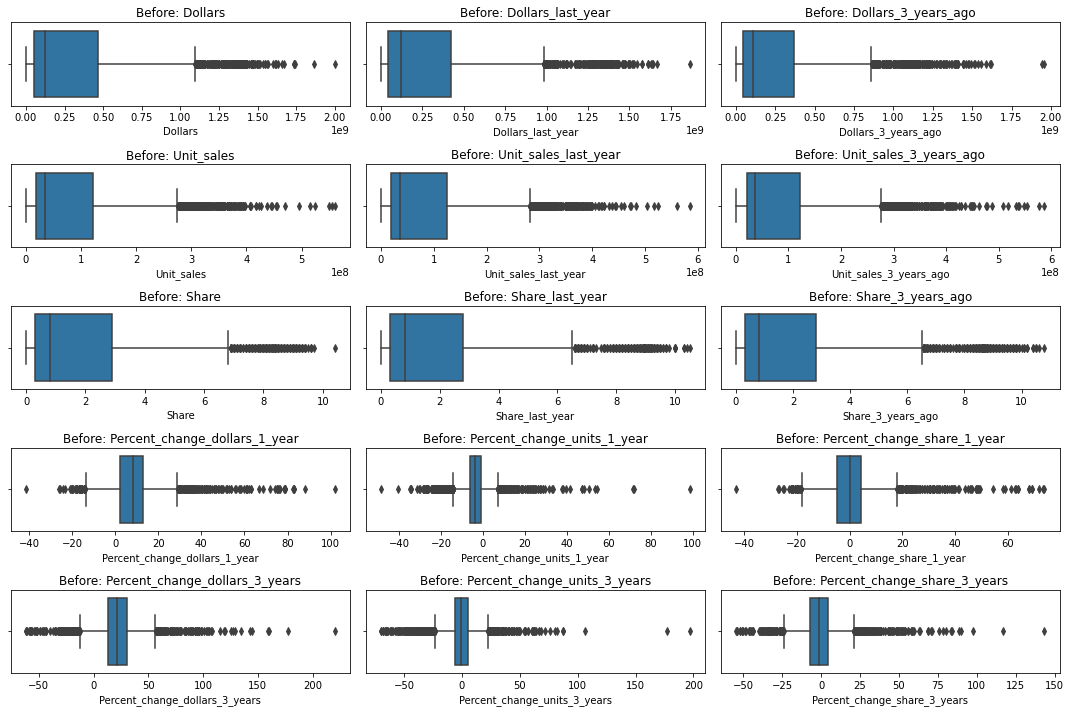

In [787]:

df = df[df['Category'] != 'All foods']

# SELECT NUMERIC COLUMNS
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# BOXPLOTS BEFORE OUTLIER HANDLING
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(5, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f"Before: {col}")

plt.tight_layout()
plt.show()

# CALCULATE IQR
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR



In [788]:
# COLUMN-WISE OUTLIER COUNT 
outlier_counts = {}

for col in numeric_cols:
    outliers_col = ((df[col] < lower_bound[col]) | (df[col] > upper_bound[col]))
    outlier_counts[col] = outliers_col.sum()

outlier_table = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier_Count'])
outlier_table = outlier_table.sort_values(by='Outlier_Count', ascending=False)

print("\nOutlier Count Per Column:")
display(outlier_table)




Outlier Count Per Column:


,Outlier_Count
Unit_sales,413
Unit_sales_last_year,410
Percent_change_units_3_years,378
Unit_sales_3_years_ago,368
Percent_change_units_1_year,337
Percent_change_dollars_3_years,296
Percent_change_share_3_years,264
Dollars_3_years_ago,256
Share_3_years_ago,254
Dollars,246


In [789]:
# CREATE OUTLIER DATAFRAME 
outliers_mask = ((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound))
df_outliers = df[outliers_mask.any(axis=1)]

print("\nNumber of rows containing outliers:", df_outliers.shape[0])




Number of rows containing outliers: 1340


In [790]:
# Clean version for display
df_outliers_clean = df_outliers.drop(['Date', 'Category', 'Subcategory'], axis=1, errors='ignore')

print("\nSample Outliers:")
display(df_outliers_clean.head())





Sample Outliers:


,Dollars,Dollars_last_year,Dollars_3_years_ago,Unit_sales,Unit_sales_last_year,Unit_sales_3_years_ago,Share,Share_last_year,Share_3_years_ago,Percent_change_dollars_1_year,Percent_change_units_1_year,Percent_change_share_1_year,Percent_change_dollars_3_years,Percent_change_units_3_years,Percent_change_share_3_years
5616,1283619666,1322610325,1.104601e+09,153248754,159439423,145532385.0,8.6,9.3,8.6,-2.9,-3.9,-7.7,16.2,5.3,-0.2
5618,870960817,788953316,7.311361e+08,311292330,317498491,325449264.0,5.8,5.5,5.7,10.4,-2.0,5.0,19.1,-4.3,2.3
5619,898159363,785749369,6.862229e+08,334202523,318964592,296950839.0,6.0,5.5,5.3,14.3,4.8,8.7,30.9,12.5,12.4
5624,950944366,855872037,8.207801e+08,315324552,310979136,307720818.0,6.4,6.0,6.4,11.1,1.4,5.7,15.9,2.5,-0.5
5625,948142554,869202974,8.252606e+08,313705620,310215804,322154166.0,6.3,6.1,6.4,9.1,1.1,3.8,14.9,-2.6,-1.4


In [791]:
# APPLY CAPPING
df_capped = df.copy()

for col in numeric_cols:
    df_capped[col] = np.where(df_capped[col] < lower_bound[col],
                             lower_bound[col],
                             df_capped[col])
    
    df_capped[col] = np.where(df_capped[col] > upper_bound[col],
                             upper_bound[col],
                             df_capped[col])

# VERIFY OUTLIERS AFTER CAPPING
new_outliers = {}

for col in numeric_cols:
    outliers_col = ((df_capped[col] < lower_bound[col]) | (df_capped[col] > upper_bound[col]))
    new_outliers[col] = outliers_col.sum()

new_outlier_table = pd.DataFrame.from_dict(new_outliers, orient='index', columns=['Remaining_Outliers'])

print("\nRemaining Outliers After Capping:")
display(new_outlier_table)




Remaining Outliers After Capping:


,Remaining_Outliers
Dollars,0
Dollars_last_year,0
Dollars_3_years_ago,0
Unit_sales,0
Unit_sales_last_year,0
Unit_sales_3_years_ago,0
Share,0
Share_last_year,0
Share_3_years_ago,0
Percent_change_dollars_1_year,0


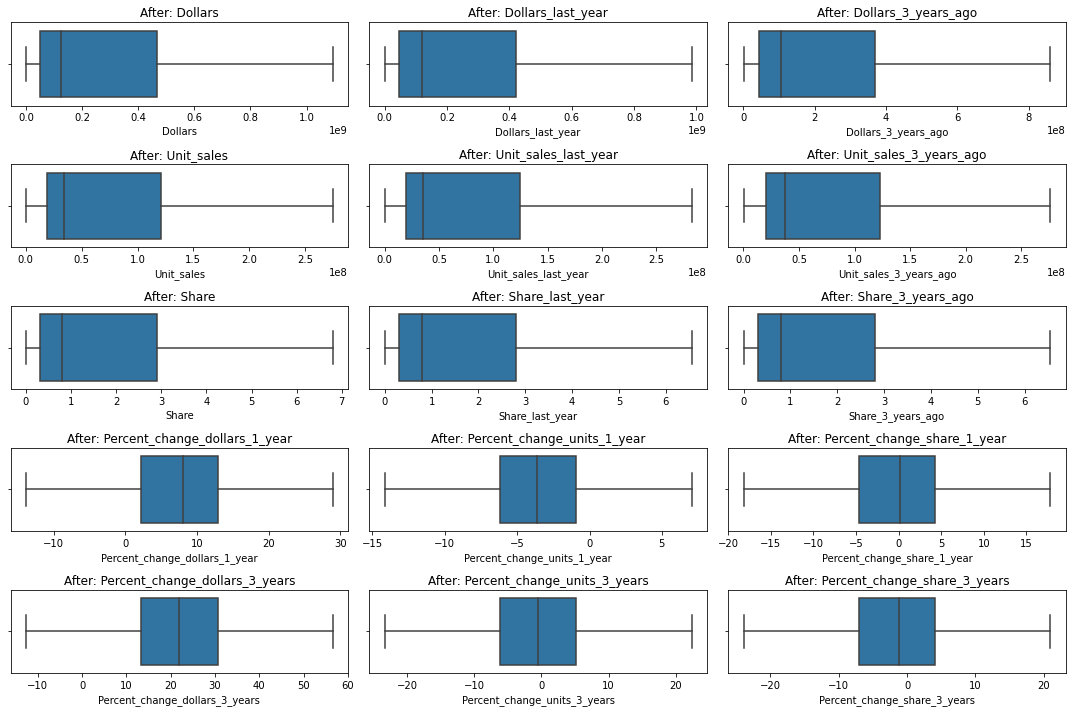

In [792]:
# BOXPLOTS AFTER OUTLIER HANDLING
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(5, 3, i)
    sns.boxplot(x=df_capped[col])
    plt.title(f"After: {col}")

plt.tight_layout()
plt.show()



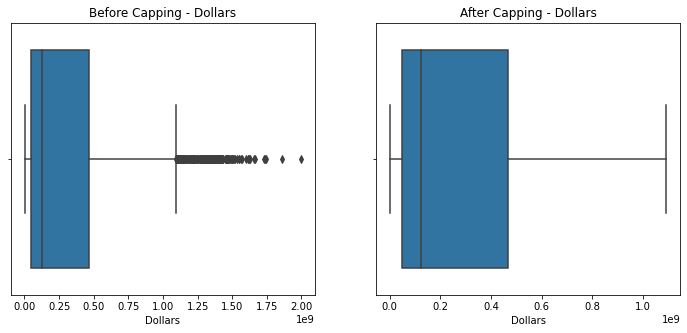

In [793]:
# BEFORE VS AFTER COMPARISON 

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['Dollars'])
plt.title("Before Capping - Dollars")

plt.subplot(1,2,2)
sns.boxplot(x=df_capped['Dollars'])
plt.title("After Capping - Dollars")

plt.show()



In [794]:
# FINAL CLEAN DATASET
df_clean = df_capped.copy()

print("\nFinal dataset ready for analysis:", df_clean.shape)

# SAVE CLEAN DATA 
df_clean.to_csv("../data/clean_data.xlsx", index=False)

print("File saved successfully!")


Final dataset ready for analysis: (4452, 18)
File saved successfully!


## Handling Outliers

Outliers are extreme values that can distort analysis and model performance.

### Observations:
- Significant outliers found in:
  - Sales (Dollars)
  - Unit Sales
  - Market Share

- These outliers are primarily from:
  - High-performing categories
  - Seasonal demand spikes

### Important:
These are **not errors**, but valuable business insights.

### Approach:
- Removed "All foods" (aggregated category)
- Applied **IQR method**
- Used **capping (winsorization)** instead of removing rows

### Insight:
Outliers reflect real-world business behavior and were handled carefully to preserve information.

## Outliers Table

In [795]:
# 5. OUTLIERS TABLE (CLEAN VERSION)
df_outliers_clean = df_outliers.drop(['Date', 'Category', 'Subcategory'], axis=1)

print("\nOutliers Table:")
display(df_outliers_clean.head())


Outliers Table:


,Dollars,Dollars_last_year,Dollars_3_years_ago,Unit_sales,Unit_sales_last_year,Unit_sales_3_years_ago,Share,Share_last_year,Share_3_years_ago,Percent_change_dollars_1_year,Percent_change_units_1_year,Percent_change_share_1_year,Percent_change_dollars_3_years,Percent_change_units_3_years,Percent_change_share_3_years
5616,1283619666,1322610325,1.104601e+09,153248754,159439423,145532385.0,8.6,9.3,8.6,-2.9,-3.9,-7.7,16.2,5.3,-0.2
5618,870960817,788953316,7.311361e+08,311292330,317498491,325449264.0,5.8,5.5,5.7,10.4,-2.0,5.0,19.1,-4.3,2.3
5619,898159363,785749369,6.862229e+08,334202523,318964592,296950839.0,6.0,5.5,5.3,14.3,4.8,8.7,30.9,12.5,12.4
5624,950944366,855872037,8.207801e+08,315324552,310979136,307720818.0,6.4,6.0,6.4,11.1,1.4,5.7,15.9,2.5,-0.5
5625,948142554,869202974,8.252606e+08,313705620,310215804,322154166.0,6.3,6.1,6.4,9.1,1.1,3.8,14.9,-2.6,-1.4


## Correlation Analysis

### 1. Full Dataset Correlation

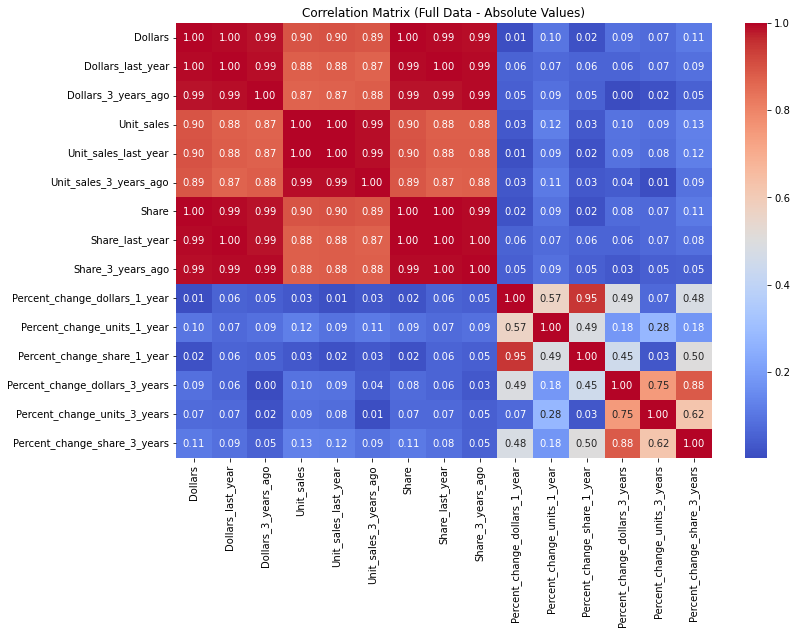

In [796]:
# Select numeric columns
full_numeric = df.select_dtypes(include=['float64', 'int64'])

# Compute correlation (absolute values)
corr_full = full_numeric.corr().abs()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_full, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix (Full Data - Absolute Values)")
plt.show()

Products with high sales in previous years tend to maintain high sales and market share.

### 2. Outliers Dataset Correlation

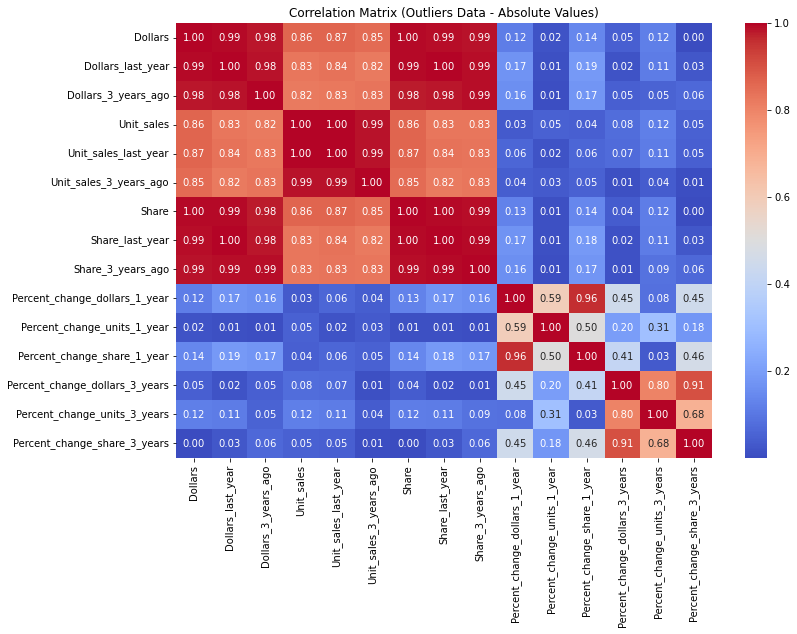

In [797]:
# Select numeric columns from outliers dataset
outliers_numeric = df_outliers.select_dtypes(include=['float64', 'int64'])

# Compute correlation (absolute values)
corr_outliers = outliers_numeric.corr().abs()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_outliers, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix (Outliers Data - Absolute Values)")
plt.show()

Outliers amplify relationships between growth variables, highlighting strong market movements during extreme periods.

##  Distribution Analysis (KDE Plots)
### KDE PLOT (FULL vs CAPPED DATA)

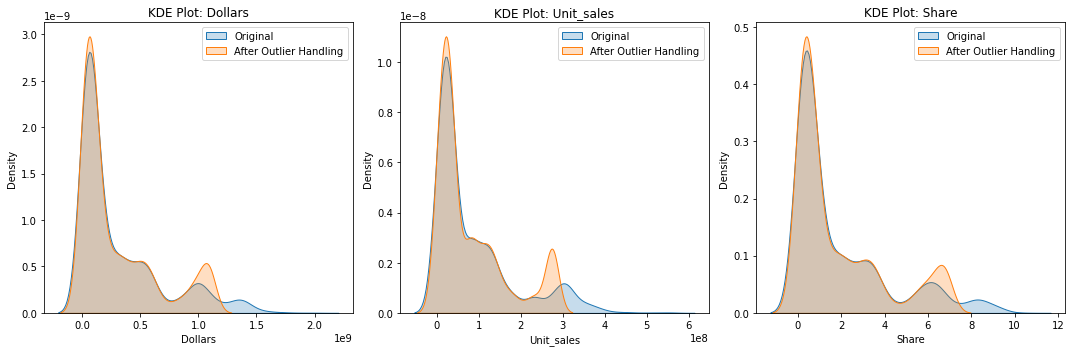

In [798]:
# Select important columns (don't plot all → too messy)
cols_to_plot = ['Dollars', 'Unit_sales', 'Share']

plt.figure(figsize=(15,5))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(1,3,i)
    
    sns.kdeplot(df[col], label='Original', fill=True)
    sns.kdeplot(df_clean[col], label='After Outlier Handling', fill=True)
    
    plt.title(f"KDE Plot: {col}")
    plt.legend()

plt.tight_layout()
plt.show()

A small number of product categories drive a disproportionately large share of total sales and units.

### KDE FOR GROWTH VARIABLES

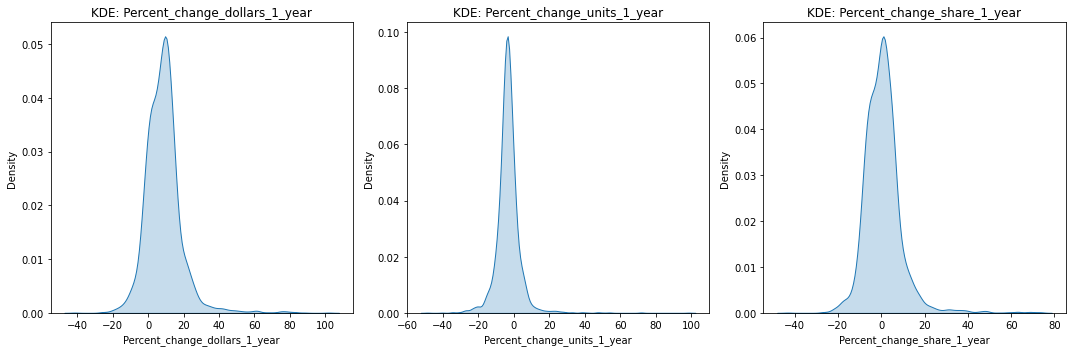

In [799]:
growth_cols = [
    'Percent_change_dollars_1_year',
    'Percent_change_units_1_year',
    'Percent_change_share_1_year'
]

plt.figure(figsize=(15,5))

for i, col in enumerate(growth_cols, 1):
    plt.subplot(1,3,i)
    
    sns.kdeplot(df[col], fill=True)
    plt.title(f"KDE: {col}")

plt.tight_layout()
plt.show()

The majority of products experience stable or moderate growth, while only a few exhibit extreme increases or declines.

## Relationship Analysis (Scatterplots)
### SCATTERPLOTS (BEFORE vs AFTER)

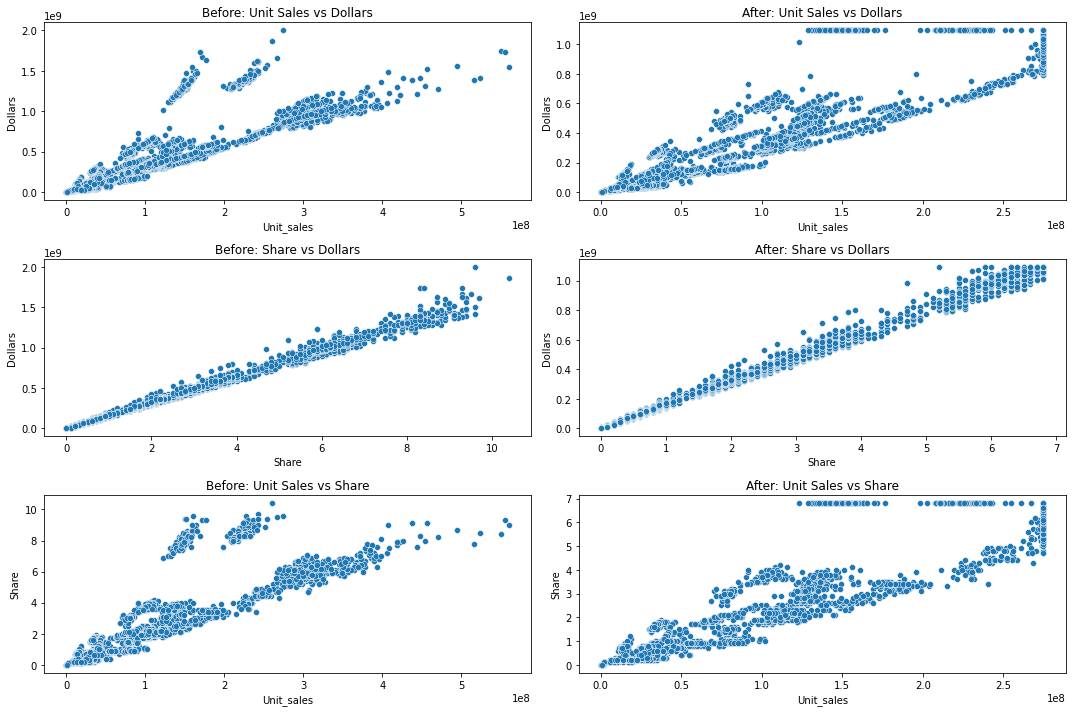

In [800]:
plt.figure(figsize=(15,10))

# Unit Sales vs Dollars
plt.subplot(3,2,1)
sns.scatterplot(x=df['Unit_sales'], y=df['Dollars'])
plt.title("Before: Unit Sales vs Dollars")

plt.subplot(3,2,2)
sns.scatterplot(x=df_clean['Unit_sales'], y=df_clean['Dollars'])
plt.title("After: Unit Sales vs Dollars")

# Share vs Dollars
plt.subplot(3,2,3)
sns.scatterplot(x=df['Share'], y=df['Dollars'])
plt.title("Before: Share vs Dollars")

plt.subplot(3,2,4)
sns.scatterplot(x=df_clean['Share'], y=df_clean['Dollars'])
plt.title("After: Share vs Dollars")

# Unit Sales vs Share
plt.subplot(3,2,5)
sns.scatterplot(x=df['Unit_sales'], y=df['Share'])
plt.title("Before: Unit Sales vs Share")

plt.subplot(3,2,6)
sns.scatterplot(x=df_clean['Unit_sales'], y=df_clean['Share'])
plt.title("After: Unit Sales vs Share")

plt.tight_layout()
plt.show()

Unit Sales vs Dollars: Revenue is highly dependent on sales volume, indicating that increasing unit sales is a key driver of overall revenue.

Share vs Dollars: Market share is strongly driven by total sales, suggesting that revenue growth directly translates into stronger market positioning.

Unit Sales vs Share: While unit sales influence market share, other factors such as pricing, product mix, and competition also play a role.

##  Data Modeling and Prediction

The goal of this section is to:

- Predict continuous values using **Linear Regression**
- Predict increase/decrease trends using **Logistic Regression**

### Models Used:
- Linear Regression → for numerical prediction
- Logistic Regression → for classification (increase/decrease)

### Important Consideration:
Highly correlated variables may lead to multicollinearity and data leakage.

In [801]:
# Drop non-numeric columns
df_model = df_clean.drop(['Date', 'Category', 'Subcategory'], axis=1, errors='ignore')

df_model.head()

,Dollars,Dollars_last_year,Dollars_3_years_ago,Unit_sales,Unit_sales_last_year,Unit_sales_3_years_ago,Share,Share_last_year,Share_3_years_ago,Percent_change_dollars_1_year,Percent_change_units_1_year,Percent_change_share_1_year,Percent_change_dollars_3_years,Percent_change_units_3_years,Percent_change_share_3_years
5616,1.093518e+09,984173461.0,8.610422e+08,153248754.0,1.594394e+08,1.455324e+08,6.8,6.55,6.55,-2.9,-3.9,-7.7,16.2,5.3,-0.2
5618,8.709608e+08,788953316.0,7.311361e+08,274847328.0,2.822811e+08,2.760437e+08,5.8,5.50,5.70,10.4,-2.0,5.0,19.1,-4.3,2.3
5619,8.981594e+08,785749369.0,6.862229e+08,274847328.0,2.822811e+08,2.760437e+08,6.0,5.50,5.30,14.3,4.8,8.7,30.9,12.5,12.4
5620,2.450492e+08,245548827.0,2.286476e+08,35634149.0,3.753970e+07,3.668153e+07,1.6,1.70,1.80,-0.2,-5.1,-5.1,7.2,-2.9,-8.0
5621,4.302721e+08,371222085.0,3.379893e+08,175098444.0,1.653321e+08,1.616820e+08,2.9,2.60,2.60,15.9,5.9,10.3,27.3,8.3,9.3


In [802]:
# TARGET VARIABLES (FOR LOGISTIC)

df_model['Sales_Increase'] = (df_model['Dollars'] > df_model['Dollars_last_year']).astype(int)
df_model['Share_Increase'] = (df_model['Share'] > df_model['Share_last_year']).astype(int)
df_model['Unit_Increase'] = (df_model['Unit_sales'] > df_model['Unit_sales_last_year']).astype(int)

## LINEAR REGRESSION

### Predict SALES (Dollars)

In [803]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features & target
X = df_model.drop(['Dollars'], axis=1)
y = df_model['Dollars']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prediction
y_pred = lr_model.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

R2 Score: 0.9991839122410872
RMSE: 9913405.889448984


### Predict MARKET SHARE

In [804]:
X = df_model.drop(['Share'], axis=1)
y = df_model['Share']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

R2 Score: 0.9992945202195055
RMSE: 0.057029420501493976


### Predict UNIT SALES

In [805]:
X = df_model.drop(['Unit_sales'], axis=1)
y = df_model['Unit_sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

R2 Score: 0.9992342720877874
RMSE: 2469995.235248893


The model shows extremely high predictive accuracy, indicating that current values are strongly dependent on historical features such as last year and 3-year data

## LOGISTIC REGRESSION

### Predict SALES INCREASE

In [806]:
X = df_model.drop(['Sales_Increase'], axis=1)
y = df_model['Sales_Increase']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       146
           1       1.00      1.00      1.00       745

    accuracy                           1.00       891
   macro avg       1.00      1.00      1.00       891
weighted avg       1.00      1.00      1.00       891



### Confusion Matrix

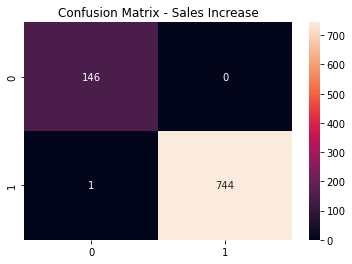

In [807]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Sales Increase")
plt.show()

Sales increase is highly predictable due to strong dependency on past sales performance.

### Share Increase

In [808]:
X = df_model.drop(['Share_Increase'], axis=1)
y = df_model['Share_Increase']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84       623
           1       0.62      0.82      0.71       268

    accuracy                           0.80       891
   macro avg       0.77      0.80      0.78       891
weighted avg       0.83      0.80      0.80       891



### Confusion Matrix

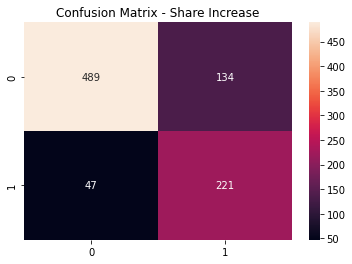

In [809]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Share Increase")
plt.show()

Market share changes are harder to predict compared to sales, as they are influenced by multiple external factors such as competition and pricing strategies.

### Unit Increase

In [810]:
X = df_model.drop(['Unit_Increase'], axis=1)
y = df_model['Unit_Increase']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       742
           1       1.00      1.00      1.00       149

    accuracy                           1.00       891
   macro avg       1.00      1.00      1.00       891
weighted avg       1.00      1.00      1.00       891



### Confusion Matrix

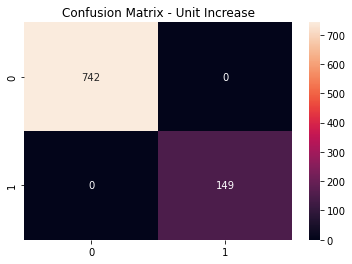

In [811]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Unit Increase")
plt.show()

Unit sales trends are highly consistent and predictable based on historical patterns.

## Model Evaluation

### Linear Regression:
- Very high R² (~0.999)
- Indicates strong predictive relationships

  However:
- This suggests possible **data leakage**
- Features like "last year" values are highly correlated with target

---

### Logistic Regression:

#### Sales & Unit Prediction:
- Near-perfect accuracy (~100%)

#### Share Prediction:
- Moderate accuracy (~80%)

### Insight:
Market share is harder to predict due to external factors.

## Final Conclusion

This analysis explored customer buying behavior across food categories using statistical analysis and machine learning models.

### Key Findings:
- Strong relationships exist between sales, unit sales, and market share
- A small number of categories drive the majority of sales
- Growth variables show more variability compared to absolute values

### Modeling Insights:
- Linear regression performed extremely well but showed signs of **data leakage**
- Logistic regression effectively predicted increase/decrease trends
- Market share prediction was more challenging due to external influences

### Limitations:
- High multicollinearity between variables
- Presence of data leakage in predictive models

### Future Improvements:
- Feature selection to reduce correlation
- Use of advanced models (Ridge, Random Forest)
- Inclusion of external factors (pricing, promotions)


---

### Final Thought:
While the models show strong performance, careful feature engineering is required to build robust and generalizable predictive systems.

### Business Impact:
This analysis can help retailers identify high-performing categories, optimize inventory, and improve sales forecasting.